In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

In [2]:
# LOAD DATASET

df = pd.read_csv("/content/drive/MyDrive/Flight-Dataset.csv")

# Display first 5 rows
print(df.head())

       Airline Date_of_Journey    Source Destination                  Route  \
0       IndiGo      24/03/2019  Banglore   New Delhi              BLR → DEL   
1    Air India       1/05/2019   Kolkata    Banglore  CCU → IXR → BBI → BLR   
2  Jet Airways       9/06/2019     Delhi      Cochin  DEL → LKO → BOM → COK   
3       IndiGo      12/05/2019   Kolkata    Banglore        CCU → NAG → BLR   
4       IndiGo      01/03/2019  Banglore   New Delhi        BLR → NAG → DEL   

  Dep_Time  Arrival_Time Duration Total_Stops Additional_Info  Price  
0    22:20  01:10 22 Mar   2h 50m    non-stop         No info   3897  
1    05:50         13:15   7h 25m     2 stops         No info   7662  
2    09:25  04:25 10 Jun      19h     2 stops         No info  13882  
3    18:05         23:30   5h 25m      1 stop         No info   6218  
4    16:50         21:35   4h 45m      1 stop         No info  13302  


In [3]:
# DATA INFORMATION

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


Columns:
Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

Missing Values:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Dura

In [4]:
import numpy as np

# DATA CLEANING

# Ensure Price column is numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# We will handle missing values after duration is processed to avoid emptying the dataframe prematurely.

In [5]:
# HANDLE DURATION COLUMN

def convert_duration(x):
    if pd.isnull(x):
        return np.nan
    x = str(x)
    hours = 0
    minutes = 0
    if 'h' in x:
        try:
            hours = int(x.split('h')[0])
        except ValueError:
            pass
    if 'm' in x:
        mins_part = x.split('h')[-1]
        mins = mins_part.replace('m', '').strip()
        if mins != '':
            try:
                minutes = int(mins)
            except ValueError:
                pass
    return hours * 60 + minutes

df['Duration'] = df['Duration'].apply(convert_duration)

# Now drop rows with missing critical values
df.dropna(subset=['Route', 'Total_Stops', 'Duration', 'Price'], inplace=True)
print(f"Dataframe shape after cleaning: {df.shape}")

Dataframe shape after cleaning: (10682, 11)


In [6]:
print(df.shape)

(10682, 11)


In [7]:
# FEATURE SELECTION

df_f = df[
    [
        'Airline',
        'Source',
        'Destination',
        'Route',
        'Duration',
        'Total_Stops',
        'Additional_Info',
        'Price'
    ]
]

In [8]:
# ENCODING CATEGORICAL VARIABLES

categorical_columns = [
    'Airline',
    'Source',
    'Destination',
    'Route',
    'Total_Stops',
    'Additional_Info'
]

df_f = pd.get_dummies(df_f, columns=categorical_columns, drop_first=True)

print("\nEncoded Dataset Shape:")
print(df_f.shape)


Encoded Dataset Shape:
(10682, 162)


In [9]:
# TRAIN TEST SPLIT

X = df_f.drop('Price', axis=1)
y = df_f['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    train_size=0.6,
    random_state=100
)

In [30]:
# LINEAR REGRESSION

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\nLinear Regression")
print("RMSE:", rmse_lr)
print("MAE :", mae_lr)
print("R2  :", r2_lr)


Linear Regression
RMSE: 2295.922217753502
MAE : 1524.927981927468
R2  : 0.7582294745387335


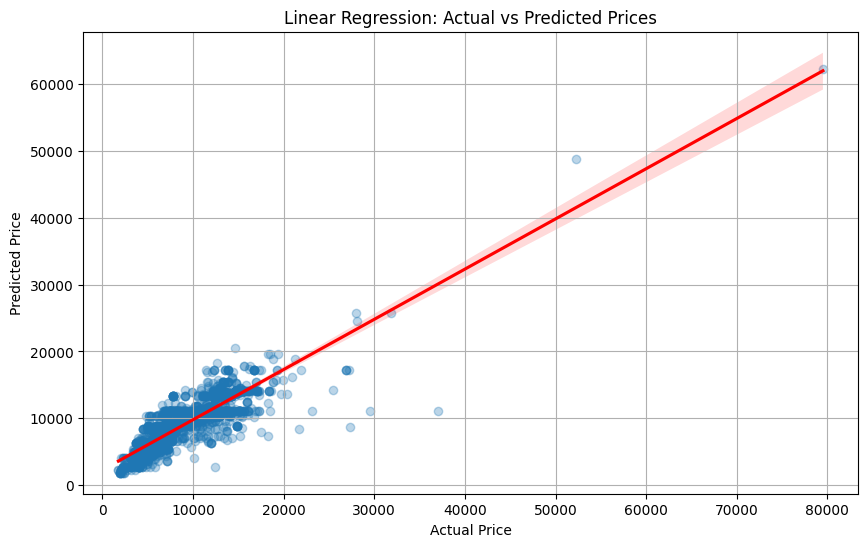

In [25]:
# VISUALIZATION FOR LINEAR REGRESSION
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred_lr, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Linear Regression: Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

In [11]:
# DECISION TREE REGRESSOR

dt = DecisionTreeRegressor(max_depth=5, random_state=0)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\nDecision Tree")
print("RMSE:", rmse_dt)
print("MAE :", mae_dt)
print("R2  :", r2_dt)


Decision Tree
RMSE: 2536.1454141304102
MAE : 1734.7335859307136
R2  : 0.704989607959791


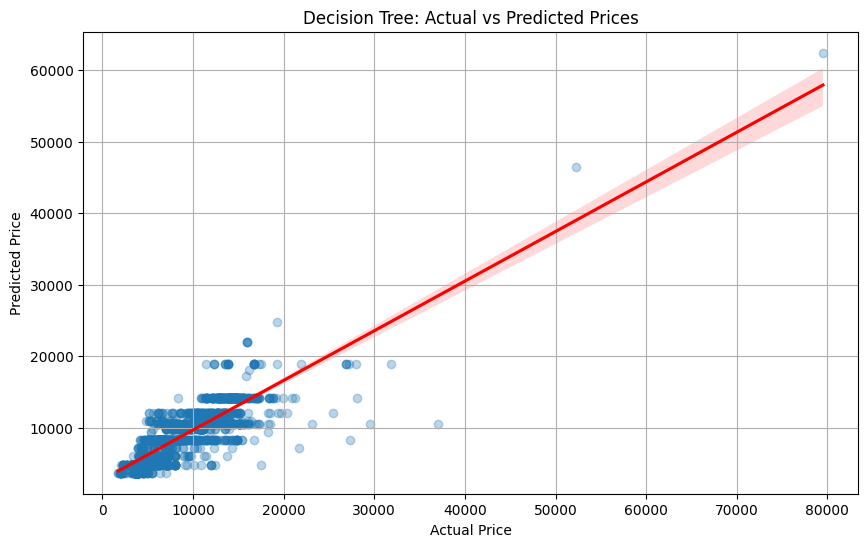

In [26]:
# VISUALIZATION FOR DECISION TREE REGRESSOR
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred_dt, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Decision Tree: Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

In [12]:
# RANDOM FOREST REGRESSOR

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=0
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest")
print("RMSE:", rmse_rf)
print("MAE :", mae_rf)
print("R2  :", r2_rf)


Random Forest
RMSE: 2278.795111706341
MAE : 1397.4609908309255
R2  : 0.7618231368415367


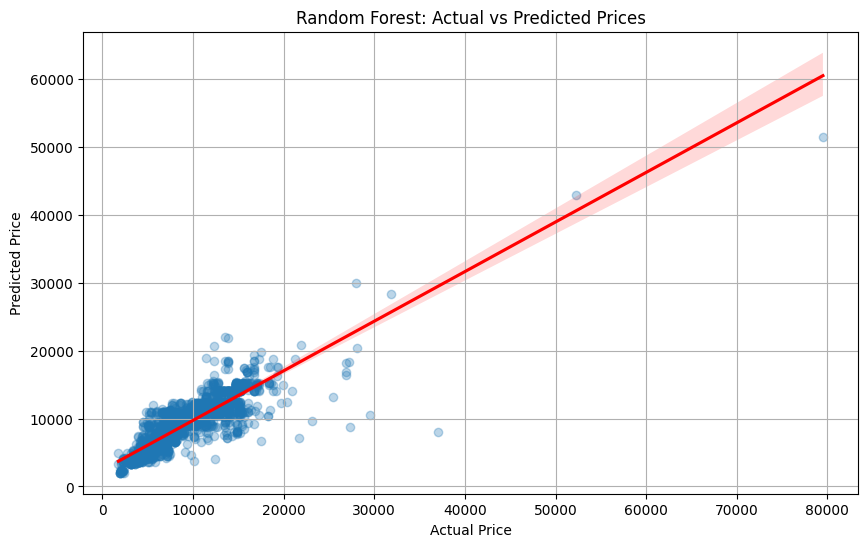

In [27]:
# VISUALIZATION FOR RANDOM FOREST REGRESSOR
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred_rf, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Random Forest: Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

In [13]:
# KNN REGRESSOR

knn = KNeighborsRegressor(n_neighbors=10)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("\nKNN Regressor")
print("RMSE:", rmse_knn)
print("MAE :", mae_knn)
print("R2  :", r2_knn)


KNN Regressor
RMSE: 3261.554795425909
MAE : 1804.9399157697706
R2  : 0.5120915143852907


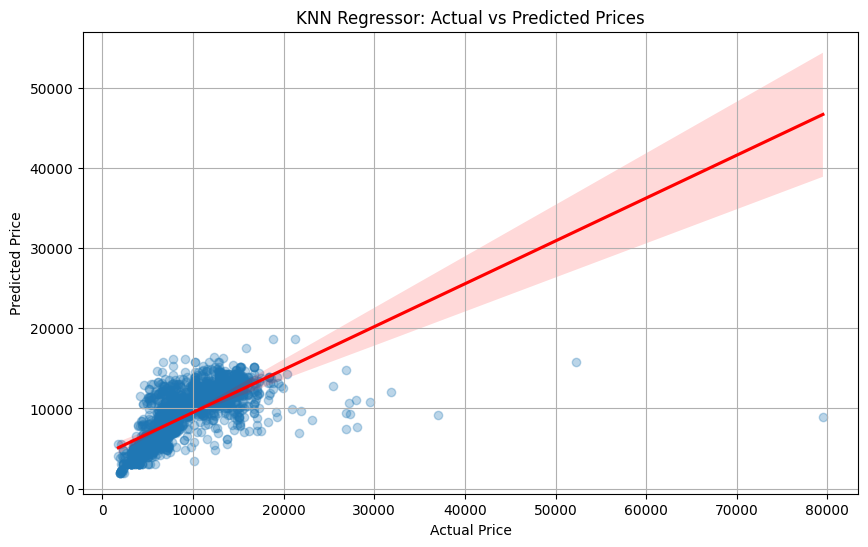

In [28]:
# VISUALIZATION FOR KNN REGRESSOR
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred_knn, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('KNN Regressor: Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

In [14]:
# MODEL COMPARISON TABLE

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],

    'R2 Score': [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_knn
    ],

    'RMSE': [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_knn
    ],

    'MAE': [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_knn
    ]
})

print("\nModel Comparison")
print(results)



Model Comparison
               Model  R2 Score         RMSE          MAE
0  Linear Regression  0.758229  2295.922218  1524.927982
1      Decision Tree  0.704990  2536.145414  1734.733586
2      Random Forest  0.761823  2278.795112  1397.460991
3                KNN  0.512092  3261.554795  1804.939916


### Visualizing Model Performance
We will now plot the R2 Score and RMSE for all trained models to compare their effectiveness.

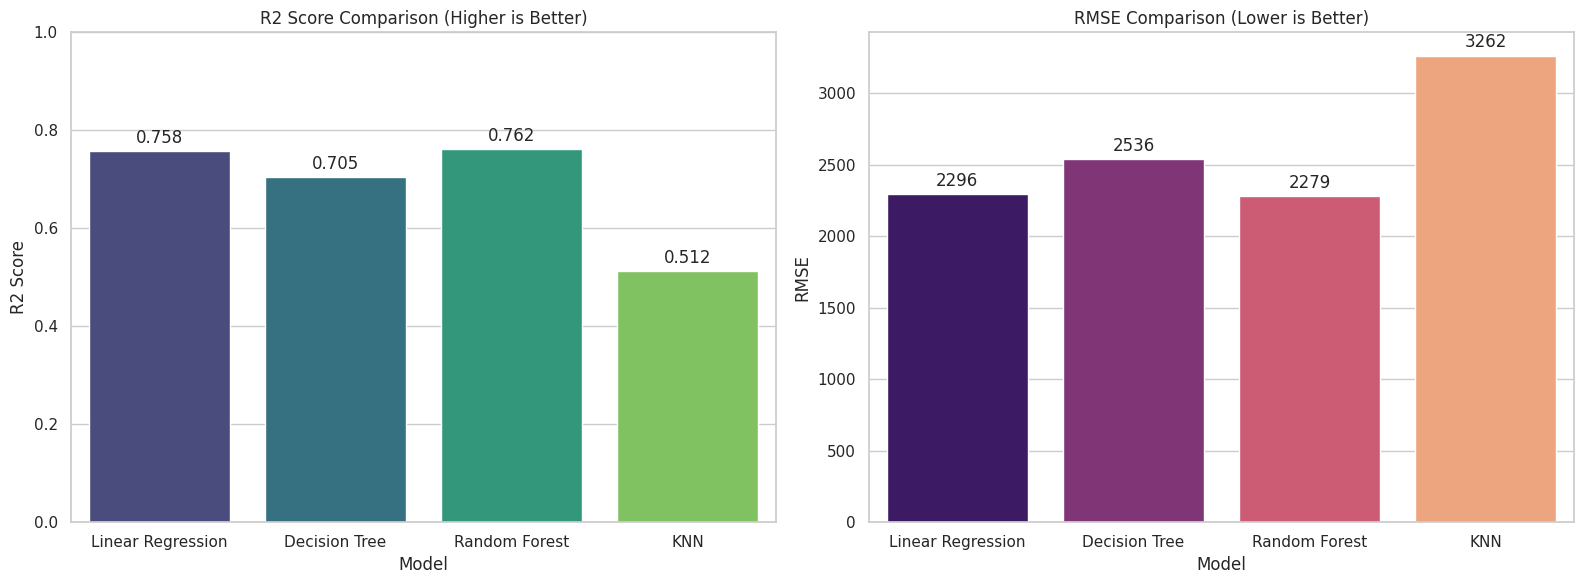

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot R2 Score
sns.barplot(x='Model', y='R2 Score', data=results, palette='viridis', ax=ax1, hue='Model', legend=False)
ax1.set_title('R2 Score Comparison (Higher is Better)')
ax1.set_ylim(0, 1.0)
for i in ax1.containers:
    ax1.bar_label(i, fmt='%.3f', padding=3)

# Plot RMSE
sns.barplot(x='Model', y='RMSE', data=results, palette='magma', ax=ax2, hue='Model', legend=False)
ax2.set_title('RMSE Comparison (Lower is Better)')
for i in ax2.containers:
    ax2.bar_label(i, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

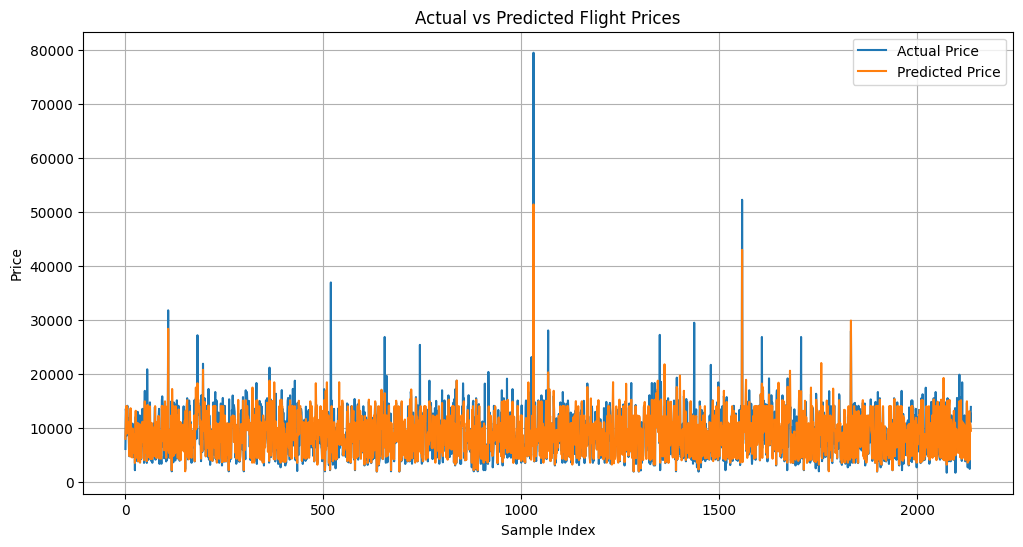

In [16]:
# ACTUAL VS PREDICTED (RANDOM FOREST)

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual Price'
)

plt.plot(
    y_pred_rf,
    label='Predicted Price'
)

plt.title('Actual vs Predicted Flight Prices')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.show()

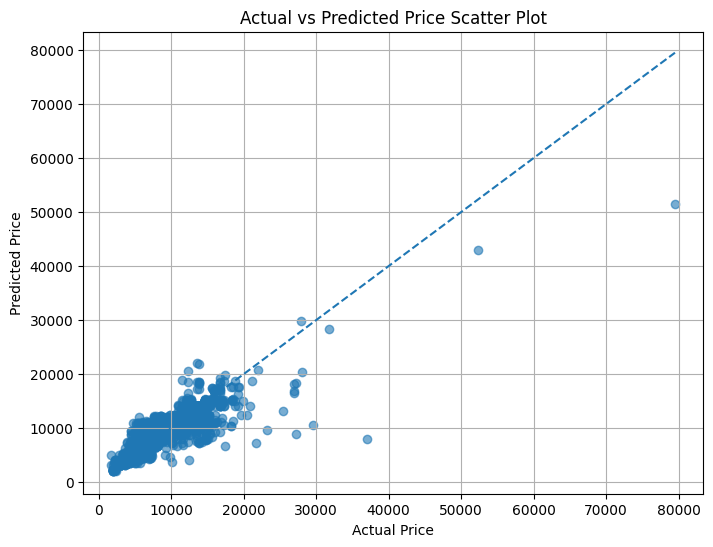

In [17]:
# SCATTER PLOT
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    '--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.title('Actual vs Predicted Price Scatter Plot')

plt.grid(True)
plt.show()